### Differences between VGP, SVGP, CMOGP, sCMOGP, sCMOGP with exact target. 
Sometimes, CMOGP does as well as the VGPs (or better, like this example), but it is quite possible to get really bad results too.

In [ ]:
import gpflow as gpf
import tensorflow as tf
import numpy as np
import sys
sys.path.append("../..")
from gpflow.models.training_mixins import InternalDataTrainingLossMixin
import matplotlib.pyplot as plt
from atlikelihood import TransferLikelihood

from gpflow.covariances.dispatch import Kuf, Kuu
from gpflow.utilities import to_default_float, assert_params_false, add_likelihood_noise_cov
from gpflow.config import default_jitter, default_float
from gpflow.utilities import to_default_float
from gpflow.models.util import InducingPointsLike, data_input_to_tensor, inducingpoint_wrapper
from gpflow.inducing_variables import InducingPoints
from typing import NamedTuple
from robust_svgp import LMCInducingPointsBase

from atmodel import ConditionalMOGP, SparseCMOGP
from atlikelihood import TransferLikelihood

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50}, method="L-BFGS-B")
    plt.plot(res["loss_history"])
    plt.show()

def get_kernel():
    return gpf.kernels.Periodic(gpf.kernels.Matern32())

2026-06-16 17:22:23.444957: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-16 17:22:23.447288: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-16 17:22:23.476944: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-16 17:22:23.477511: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-16 17:22:24.313718: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

[  0  10  20  30  40  50  60  70  80  90 100 110 120 130 140 150 160 170
 180 190]


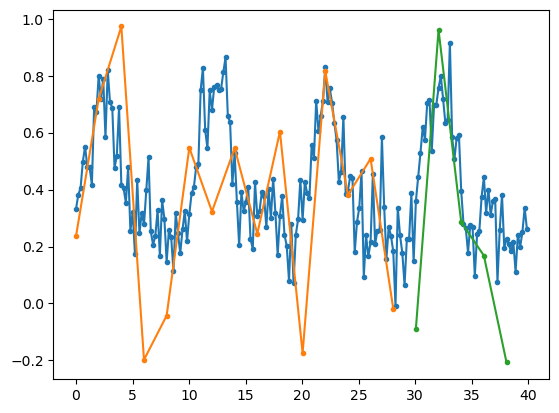

In [ ]:
k = gpf.kernels.Periodic(gpf.kernels.RBF(), period=10)
Xall = np.linspace(0, 100, 500)
Yall  = np.random.multivariate_normal(np.zeros_like(Xall), k(Xall.reshape(-1, 1)))
ind_1 = np.arange(0, 200, 1)
ind_2 = np.array([i for i in ind_1 if i % 10 == 0])
ind_1 = ind_1
ind_2 = ind_2 
print(ind_2)
TEST_INDEX = int(0.75*len(ind_2))
ind_train, ind_test = ind_2[:TEST_INDEX], ind_2[TEST_INDEX:]
X1, y1 = Xall[ind_1], Yall[ind_1]
y1 =  y1 #+  np.random.multivariate_normal(np.zeros_like(Xall), k(Xall.reshape(-1, 1)))

X2, y2 = Xall[ind_train], Yall[ind_train]
X2 = X2 - X2[0]
scalar = 1
y2 = scalar * Yall[ind_1] # np.roll(y2, 5)
#k = gpf.kernels.Cosine(lengthscales=1, variance=1) #+ gpf.kernels.Linear(0.001)
y2 = y2[ind_train] 
Xtest, ytest = Xall[ind_test], Yall[ind_test]
ytest = (scalar * ytest).reshape(-1, 1)


y1 = y1.reshape(-1, 1) + np.random.normal(0, 0.1, len(X1)).reshape(-1, 1)
y2 = y2.reshape(-1, 1) + np.random.normal(0, 0.3, len(X2)).reshape(-1, 1) 
ytest = ytest.reshape(-1, 1) + np.random.normal(0, 0.3, len(Xtest)).reshape(-1, 1) 
X1 = X1.reshape(-1, 1)
X2 = X2.reshape(-1, 1)
y2 = y2 
plt.plot(X1, y1, marker=".")
plt.plot(X2, y2, marker=".")
plt.plot(Xtest, ytest, marker=".")
X = np.vstack((np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2)))))
y = np.vstack((np.hstack((y1, np.zeros_like(y1))), np.hstack((y2, np.ones_like(y2)))))
plt.show()
X = tf.cast(X, np.float64)
y = tf.cast(y, np.float64)

### CMOGP
For some reason the target variance keeps collapsing here. predict_y is a little broken for this one, I have not gotten around to fixing that.

╒═══════════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                                                      │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value   │
╞═══════════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ ConditionalMOGP.kernel.kernels[0].kernels[0].variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├───────────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ ConditionalMOGP.kernel.kernels[0].kernels[0].lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├───────────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼──

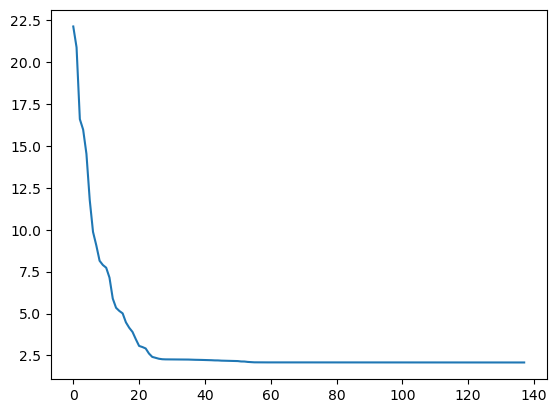

╒═══════════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════════════════════╕
│ name                                                      │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                           │
╞═══════════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════════════════════╡
│ ConditionalMOGP.kernel.kernels[0].kernels[0].variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 9.152277949225107e-05           │
├───────────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────────────────┤
│ ConditionalMOGP.kernel.kernels[0].kernels[0].lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.321119

In [ ]:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = get_kernel() 

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)


ivs = np.linspace(0, max(X[:,0]), 50).reshape(-1, 1)
iv_ind = np.concatenate((np.ones((25,1 )), np.zeros((25, 1))))
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))
kern = k * coreg 
m = ConditionalMOGP((X, y), kernel=kern, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#gpf.set_trainable(m.kernel.kernels[0].variance, True)
#gpf.set_trainable(m.likelihood.source.variance, False)

gpf.utilities.print_summary(m)
optimize(m)
gpf.utilities.print_summary(m)

TensorShape([215, 500])
TensorShape([215, 5])


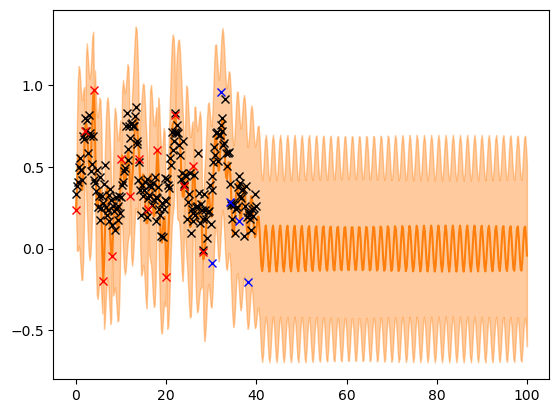

0.06846677230118248

In [ ]:
from sklearn.metrics import mean_squared_error
Xall = Xall.reshape(-1, 1)
Xtst = Xtest.reshape(-1, 1)
Xplot = np.hstack((Xall, np.ones_like(Xall)))
Xtst = np.hstack((Xtst, np.ones_like(Xtst)))
fmean, fvar = m.predict_f(Xplot)
fmean_tst, fvar_tst = m.predict_f(Xtst)
plt.plot(Xall, fmean, color="C1")
plt.plot(X1, y1, "kx")
plt.plot(X2, y2, "rx")
plt.plot(Xtest, ytest, "bx")
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.show()

cmogp_mse = mean_squared_error(ytest, fmean_tst)
cmogp_mse

# sparse CMOGP with approximate target
(that is, Kbb is approximated via the inducing variables too, so the covariance of the objective is $Q_{t|s} = \begin{bmatrix} Q_{tt} + \Lambda_t & Q_{ts} \\ Q_{st} & Q_{ss} + \Lambda_s \end{bmatrix}$)

╒═══════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤══════════════╕
│ name                                                  │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value        │
╞═══════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪══════════════╡
│ SparseCMOGP.kernel.kernels[0].kernels[0].variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0          │
├───────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼──────────────┤
│ SparseCMOGP.kernel.kernels[0].kernels[0].lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0          │
├───────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼

2026-06-16 18:06:50.525565: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-06-16 18:06:50.530795: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.


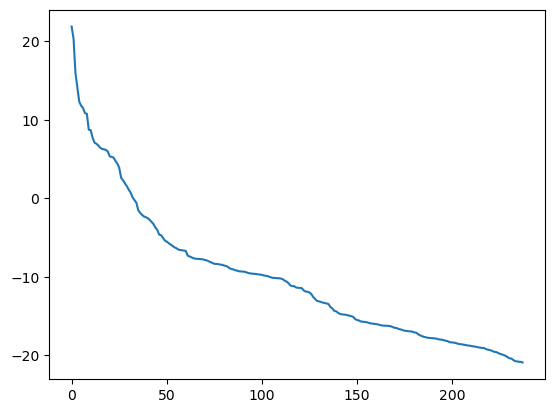

╒═══════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════════════════════╕
│ name                                                  │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                           │
╞═══════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].kernels[0].variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.00011169916078016979          │
├───────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].kernels[0].lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.11752                         

In [ ]:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = get_kernel() 

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

ivs = np.linspace(0, max(X[:,0]), 50).reshape(-1, 1)
iv_ind = np.concatenate((np.ones((25,1 )), np.zeros((25, 1))))
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))
kern = k * coreg
m = SparseCMOGP((X, y), exact_target=False, kernel=kern, jitter=1e-6, inducing_variable=ivs, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#gpf.set_trainable(m.kernel.kernels[0].variance, True)
#gpf.set_trainable(m.likelihood.source.variance, False)

gpf.utilities.print_summary(m)
optimize(m)
gpf.utilities.print_summary(m)

In [ ]:
def plot_gp(x, mu, var, color, label):
    plt.plot(x, mu, color=color, lw=2, label=label)
    plt.fill_between(
        x[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color=color,
        alpha=0.4,
    )


def plot(m):
    plt.figure(figsize=(8, 4))
    Xtest = np.linspace(0, 1, 100)[:, None]
    (line,) = plt.plot(X1, Y1, "x", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.zeros_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y1")

    (line,) = plt.plot(X2, Y2, "x", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.ones_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y2")
    ivs = m.inducing_variable.Z.numpy() 
    plt.scatter(ivs, np.zeros_like(ivs))
    plt.legend()
    return np.mean((mu - Xtest) ** 2)
 

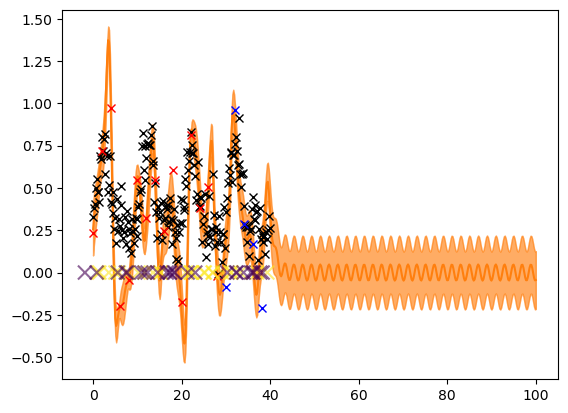

0.04369008425537031

In [ ]:
from sklearn.metrics import mean_squared_error
Xall = Xall.reshape(-1, 1)
Xtst = Xtest.reshape(-1, 1)
Xplot = np.hstack((Xall, np.ones_like(Xall)))
Xtst = np.hstack((Xtst, np.ones_like(Xtst)))
fmean, fvar = m.predict_f(Xplot)
fmean_tst, fvar_tst = m.predict_f(Xtst)
ymean, yvar = m.predict_y(Xplot)
plt.plot(Xall, fmean, color="C1")
plt.plot(X1, y1, "kx")
plt.plot(X2, y2, "rx")
plt.plot(Xtest, ytest, "bx")
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.fill_between(
    Xall[:, 0],
    (ymean - 2 * np.sqrt(yvar))[:, 0],
    (ymean + 2 * np.sqrt(yvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.scatter(m.inducing_variable.Z[:,0], np.ones_like(ivs[:,0])*0, marker="x", c=ivs[:,1], zorder=100, s=100, alpha=0.6)
plt.show()


ours_variance = m.likelihood.target.variance.numpy()

ours_mse = mean_squared_error(ytest, fmean_tst)
ours_mse

### Sparse MOGP with exact target 
If the target is not super big, you can also use the exact target (sometimes, it can technically become inconsistent), so the covariance of the target given source used in the objective is, 
$Q_{t|s} = \begin{bmatrix} K_{tt} + \Lambda_t & Q_{ts} \\ Q_{st} & Q_{ss} + \Lambda_s \end{bmatrix}$

╒═══════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤══════════════╕
│ name                                                  │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value        │
╞═══════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪══════════════╡
│ SparseCMOGP.kernel.kernels[0].kernels[0].variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0          │
├───────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼──────────────┤
│ SparseCMOGP.kernel.kernels[0].kernels[0].lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0          │
├───────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼

2026-06-16 18:07:04.004072: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-06-16 18:07:04.006769: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-06-16 18:07:04.009710: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-06-16 18:07:04.012636: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-06-16 18:07:04.016131: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular out

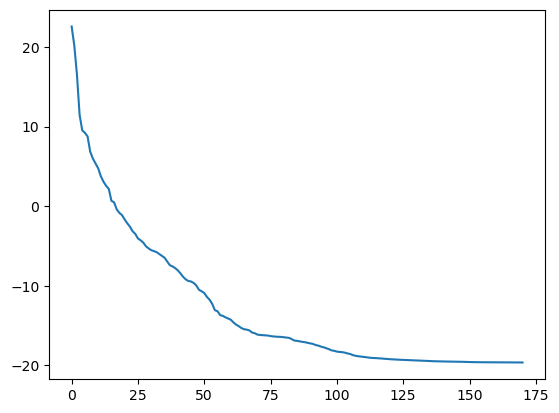

╒═══════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════════════════════╕
│ name                                                  │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                           │
╞═══════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].kernels[0].variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 3.352668566180396e-05           │
├───────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].kernels[0].lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.7851468132501829              

In [ ]:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = get_kernel()

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

ivs = np.linspace(0, max(X[:,0]), 50).reshape(-1, 1)
iv_ind = np.concatenate((np.ones((25,1 )), np.zeros((25, 1))))  # I guess the IPs for the target don't matter here, but this makes the comparison fair.
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))
kern = k * coreg
m = SparseCMOGP((X, y), exact_target=True, kernel=kern, jitter=1e-6, inducing_variable=ivs, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#gpf.set_trainable(m.kernel.kernels[0].variance, True)
#gpf.set_trainable(m.likelihood.source.variance, False)

gpf.utilities.print_summary(m)
optimize(m)
gpf.utilities.print_summary(m)

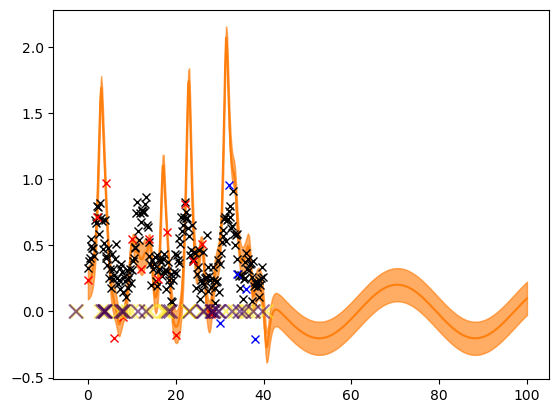

0.2148317406227597

In [ ]:
from sklearn.metrics import mean_squared_error
Xall = Xall.reshape(-1, 1)
Xtst = Xtest.reshape(-1, 1)
Xplot = np.hstack((Xall, np.ones_like(Xall)))
Xtst = np.hstack((Xtst, np.ones_like(Xtst)))
fmean, fvar = m.predict_f(Xplot)
fmean_tst, fvar_tst = m.predict_f(Xtst)
ymean, yvar = m.predict_y(Xplot)
plt.plot(Xall, fmean, color="C1")
plt.plot(X1, y1, "kx")
plt.plot(X2, y2, "rx")
plt.plot(Xtest, ytest, "bx")
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.fill_between(
    Xall[:, 0],
    (ymean - 2 * np.sqrt(yvar))[:, 0],
    (ymean + 2 * np.sqrt(yvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.scatter(m.inducing_variable.Z[:,0], np.ones_like(ivs[:,0])*0, marker="x", c=ivs[:,1], zorder=100, s=100, alpha=0.6)
plt.show()

ours_exact_mse = mean_squared_error(ytest, fmean_tst)
ours_exact_mse

### SVGP

I don't think this is technically valid, because the indices (which the coregion kernel needs) of the inducing points are never fixed. 

In [ ]:
# This likelihood switches between Gaussian noise with different variances for each f_i:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = get_kernel()

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg

lik = TransferLikelihood(
    source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()
)

ivs = np.linspace(0, max(X[:,0]), 50).reshape(-1, 1)
iv_ind = np.concatenate((np.ones((25,1 )), np.zeros((25, 1))))
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))
X = np.vstack((np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2)))))
y = np.vstack((np.hstack((y1, np.zeros_like(y1))), np.hstack((y2, np.ones_like(y2)))))
# now build the GP model as normal
m = gpf.models.SVGP(kernel=kern, likelihood=lik, num_data=len(X), inducing_variable=LMCInducingPointsBase(ivs))

# fit the covariance function parameters
gpf.optimizers.Scipy().minimize(
    m.training_loss_closure((X, y)),
    m.trainable_variables,
    method="L-BFGS-B",
)

2026-06-16 18:07:06.655045: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-06-16 18:07:06.691891: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -121.63873022207424
        x: [ 5.635e-01  6.944e-01 ... -4.559e+00 -2.353e+00]
      nit: 1317
      jac: [ 3.711e-03 -1.114e-02 ... -2.776e-04  1.987e-05]
     nfev: 1415
     njev: 1415
 hess_inv: <1335x1335 LbfgsInvHessProduct with dtype=float64>

tf.Tensor(
[[ 3.19827049e-01  3.19827049e-01]
 [ 3.48267767e-01  3.48267767e-01]
 [ 3.77894636e-01  3.77894636e-01]
 [ 4.08315594e-01  4.08315594e-01]
 [ 4.39056983e-01  4.39056983e-01]
 [ 4.69578347e-01  4.69578347e-01]
 [ 4.99262986e-01  4.99262986e-01]
 [ 5.27469674e-01  5.27469674e-01]
 [ 5.53565135e-01  5.53565135e-01]
 [ 5.76863809e-01  5.76863809e-01]
 [ 5.96267451e-01  5.96267451e-01]
 [ 6.10632928e-01  6.10632928e-01]
 [ 6.19025723e-01  6.19025723e-01]
 [ 6.20797419e-01  6.20797419e-01]
 [ 6.15618565e-01  6.15618565e-01]
 [ 6.03443570e-01  6.03443570e-01]
 [ 5.84422945e-01  5.84422945e-01]
 [ 5.58931967e-01  5.58931967e-01]
 [ 5.28491730e-01  5.28491730e-01]
 [ 4.95098438e-01  4.95098438e-01]
 [ 4.60545394e-01  4.60545394e-01]
 [ 4.26340333e-01  4.26340333e-01]
 [ 3.93665617e-01  3.93665617e-01]
 [ 3.63394644e-01  3.63394644e-01]
 [ 3.36155004e-01  3.36155004e-01]
 [ 3.12387682e-01  3.12387682e-01]
 [ 2.92154176e-01  2.92154176e-01]
 [ 2.75276705e-01  2.75276705e-01]
 [ 2.6157

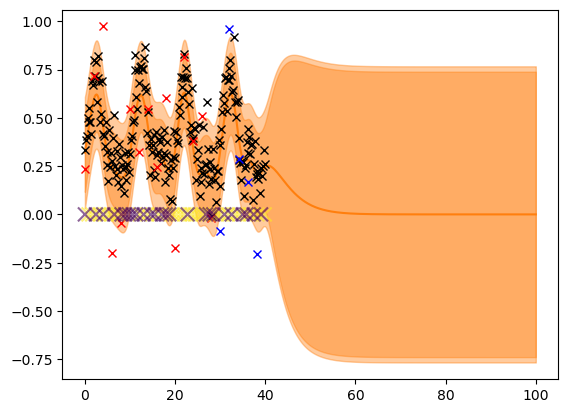

0.09955637939416302

In [ ]:
from sklearn.metrics import mean_squared_error
Xall = Xall.reshape(-1, 1)
Xtst = Xtest.reshape(-1, 1)
Xplot = np.hstack((Xall, np.ones_like(Xall)))
Xtst = np.hstack((Xtst, np.ones_like(Xtst)))
fmean, fvar = m.predict_f(Xplot)
fmean_tst, fvar_tst = m.predict_f(Xtst)
ymean, yvar = m.predict_y(Xplot)
print(ymean, yvar)
plt.plot(Xall, fmean, color="C1")
plt.plot(X1, y1, "kx")
plt.plot(X2, y2, "rx")
plt.plot(Xtest, ytest, "bx")
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.fill_between(
    Xall[:, 0],
    (ymean - 2 * np.sqrt(yvar))[:, 0],
    (ymean + 2 * np.sqrt(yvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.scatter(m.inducing_variable.Z[:,0], np.ones_like(ivs)[:,0]*0, marker="x", c=ivs[:,1], zorder=100, s=100, alpha=0.6)
plt.show()
svgp_variance = m.likelihood.likelihoods[0].variance.numpy()
svgp_mse= mean_squared_error(ytest, fmean_tst)
svgp_mse

### Direct MSE comparison

In [ ]:
print("CMOGP\t\t\t\t", cmogp_mse)
print("sCMOGP, approximate target\t", ours_mse, ours_variance)
print("sCMOGP, exact target\t\t", ours_exact_mse)
print("SVGP \t\t\t\t", svgp_mse, svgp_variance)

CMOGP				 0.06846677230118248
sCMOGP, approximate target	 0.04369008425537031 2.2947528671213877e-06
sCMOGP, exact target		 0.2148317406227597
SVGP 				 0.09955637939416302 0.010419682271829014
